# **Financial Distress & SC_risk under Sharia debt screens**

This study tests whether **Halal debt limits** act as a structural buffer against corporate distress during rate-hike cycles. We build a composite distress factor (**SC_risk**) from **Altman Z-Score** (accounting) and **Merton Distance-to-Default** (market-implied), then compare **Halal** vs **Non-Halal** cohorts on decile spreads, tail risk, and performance through tightening regimes.

## Setup

Install dependencies and configure the backtest window.

`FAST_MODE = False` uses the full S&P 500 (slower: SEC / yfinance calls). Keep it `True` only for a smoke test. Performance stats start on the first day a decile book actually holds stocks, not on `START`.

In [3]:
%pip install -q halalquant yfinance matplotlib requests scipy

import time
import warnings
from datetime import date
from io import StringIO
from pathlib import Path

import requests
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from halalquant.providers._yfinance import _map_yahoo_activity, _ticker_info
from halalquant.screening._aaoifi import AAOIFIScreener
from halalquant.screening._sector_filter import SectorFilter
from scipy.stats import rankdata

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

# --- Backtest configuration ---
START = "2019-01-01"
END = "2024-12-31"
REBALANCE_FREQ = "QE"           # quarterly, aligned with earnings
DEBT_THRESHOLD = 0.33           # research plan: debt / assets < 33%
FILING_LAG_DAYS = 60            # 45–60 day SEC filing lag
STATUTORY_TAX = 0.21
MERTON_T = 1.0                  # DD horizon (years)
MERTON_RF = 0.02                # risk-free for DD
N_DECILES = 10
MIN_DECILE_SIZE = 3
FAST_MODE = False
if FAST_MODE:
    N_DECILES = 5
    MIN_DECILE_SIZE = 2
RISK_FREE_RATE = 0.02
COST_BPS = 10
SHORT_BORROW_ANN = 0.05         # illustrative short-leg drag
HALAL_LABEL = "Halal low-distress (D10)"
NON_HALAL_LABEL = "Non-Halal low-distress (D10)"
SPREAD_HALAL_LABEL = "Halal D10 − D1 spread"
SPREAD_NON_HALAL_LABEL = "Non-Halal D10 − D1 spread"

BENCHMARKS = {
    "S&P 500": "SPY",
    "Halal (SPUS)": "SPUS",
}

RATE_HIKE_WINDOWS = [
    ("2004-06-01", "2006-06-30"),
    ("2015-12-01", "2018-12-31"),
    ("2022-03-01", "2023-07-31"),
]

fig_dir = Path.cwd() / "figures"
if not (Path.cwd() / "code.ipynb").exists():
    fig_dir = Path.cwd() / "Research" / "papers" / "03-financial-distress" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

print(f"halalquant v{hq.__version__}")
print(f"FAST_MODE={FAST_MODE}  REBALANCE_FREQ={REBALANCE_FREQ}")


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
halalquant v0.1.0
FAST_MODE=False  REBALANCE_FREQ=QE


## Step 1 — Start with a universe of stocks

We use **S&P 500 constituents** as the broad US equity universe, then pre-filter excluded business activities (banks, alcohol, gambling, etc.) using `halalquant`'s sector screen. **Halal vs Non-Halal** is determined at each rebalance by AAOIFI financial screens — not by sector alone.

In [4]:
FALLBACK_SP500 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "LLY", "AVGO", "JPM",
    "UNH", "XOM", "V", "MA", "PG", "COST", "HD", "JNJ", "ABBV", "NFLX",
    "CRM", "MRK", "AMD", "PEP", "KO", "TMO", "ADBE", "WMT", "CSCO", "ACN",
]


def load_sp500_constituents() -> pd.DataFrame:
    """One Wikipedia fetch: tickers + GICS labels (avoids 500+ Yahoo info calls)."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "MontereyFinanceResearch/1.0"}
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        table = pd.read_html(StringIO(response.text), attrs={"id": "constituents"})[0]
        out = pd.DataFrame(
            {
                "symbol": table["Symbol"].astype(str).str.replace(".", "-", regex=False),
                "gics_sector": table["GICS Sector"].astype(str),
                "gics_industry": table["GICS Sub-Industry"].astype(str),
            }
        )
        return out.drop_duplicates("symbol")
    except Exception as exc:
        print(f"Could not fetch S&P 500 list ({exc}); using fallback basket.")
        return pd.DataFrame(
            {"symbol": FALLBACK_SP500, "gics_sector": "Unclassified", "gics_industry": "Unclassified"}
        )


def _ticker_info_with_retry(symbol: str, max_attempts: int = 4, pause: float = 1.5) -> dict:
    """Yahoo info with backoff — only used when Wikipedia labels are missing."""
    for attempt in range(max_attempts):
        try:
            return _ticker_info(yf.Ticker(symbol))
        except Exception as exc:
            if attempt == max_attempts - 1:
                print(f"  Warning: Yahoo info failed for {symbol} ({exc})")
                return {}
            time.sleep(pause * (attempt + 1))
    return {}


def apply_sector_screen(
    tickers: list[str],
    constituents: pd.DataFrame | None = None,
) -> tuple[list[str], pd.DataFrame, pd.DataFrame]:
    """Sector screen using Wikipedia GICS; Yahoo fallback only for gaps."""
    wiki = constituents.set_index("symbol") if constituents is not None and not constituents.empty else pd.DataFrame()
    sector_map: dict[str, str] = {}
    gics_rows: list[dict] = []
    yahoo_fallback: list[str] = []

    for symbol in tickers:
        if symbol in wiki.index:
            y_sector = str(wiki.at[symbol, "gics_sector"])
            y_industry = str(wiki.at[symbol, "gics_industry"])
        else:
            yahoo_fallback.append(symbol)
            y_sector = ""
            y_industry = ""
        mapped = _map_yahoo_activity(y_sector, y_industry)
        if mapped:
            sector_map[symbol] = mapped
        gics_rows.append(
            {
                "symbol": symbol,
                "gics_sector": y_sector or "Unclassified",
                "gics_industry": y_industry or "Unclassified",
            }
        )

    if yahoo_fallback:
        print(f"  Yahoo fallback for {len(yahoo_fallback)} symbols missing Wikipedia GICS …", flush=True)
        for i, symbol in enumerate(yahoo_fallback, 1):
            if i == 1 or i % 25 == 0 or i == len(yahoo_fallback):
                print(f"    Yahoo info {i}/{len(yahoo_fallback)}", flush=True)
            info = _ticker_info_with_retry(symbol)
            y_sector = str(info.get("sector") or "")
            y_industry = str(info.get("industry") or "")
            mapped = _map_yahoo_activity(y_sector, y_industry)
            if mapped:
                sector_map[symbol] = mapped
            for row in gics_rows:
                if row["symbol"] == symbol:
                    row["gics_sector"] = y_sector or row["gics_sector"]
                    row["gics_industry"] = y_industry or row["gics_industry"]
                    break
            time.sleep(0.15)

    sector_filter = SectorFilter()
    kept = sector_filter.filter_symbols(tickers, sector_map=sector_map)
    audit = pd.DataFrame(sector_filter.audit_log)
    gics = pd.DataFrame(gics_rows).set_index("symbol")
    return kept, audit, gics


constituents = load_sp500_constituents()
raw_universe = constituents["symbol"].tolist()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.\n")

eligible_universe, sector_audit, gics = apply_sector_screen(raw_universe, constituents)
print(f"Raw universe:      {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")
print(f"Removed by sector:   {len(raw_universe) - len(eligible_universe)}")
sector_audit.head(10)

Raw universe:      503 tickers
After sector screen: 428 tickers
Removed by sector:   75


,symbol,sector,reason
0,AFL,conventional insurance,excluded business activity
1,ALL,conventional insurance,excluded business activity
2,MO,tobacco,excluded business activity
3,AIG,conventional insurance,excluded business activity
4,AMP,conventional banking,excluded business activity
5,AON,conventional insurance,excluded business activity
6,APO,conventional banking,excluded business activity
7,ACGL,conventional insurance,excluded business activity
8,ARES,conventional banking,excluded business activity
9,AJG,conventional insurance,excluded business activity


## Steps 2–6 — Score SC_risk, split cohorts, build deciles, rebalance

Pipeline at each rebalance date (point-in-time, no look-ahead):

1. **SCORE** — Altman Z-Score and Merton Distance-to-Default from lagged fundamentals + market data
2. **COMBINE** — `SC_risk` = average percentile rank of inverted Z and inverted DD (**higher = more distress**)
3. **COHORT** — **Halal** = passes AAOIFI screens (`debt / 24m mcap < 33%`); **Non-Halal** = eligible names that fail
4. **DECILES** — rank `SC_risk` within each cohort; **D1** = highest distress, **D10** = lowest
5. **PORTFOLIOS** — equal-weight decile books; long-short = **D10 − D1** spread per cohort
6. **REBALANCE** — quarterly (`REBALANCE_FREQ = "QE"`)

In [5]:
EBIT_ALIASES = ("EBIT", "Operating Income")
PRETAX_ALIASES = ("Pretax Income", "EBT")
TAX_ALIASES = ("Tax Provision", "Tax Expense")
REVENUE_ALIASES = ("Total Revenue", "Operating Revenue")
EQUITY_ALIASES = (
    "Stockholders Equity",
    "Common Stock Equity",
    "Total Equity Gross Minority Interest",
    "Total Stockholder Equity",
)
DEBT_ALIASES = ("Total Debt",)
CASH_ALIASES = (
    "Cash And Cash Equivalents",
    "Cash Cash Equivalents And Short Term Investments",
)
CURRENT_ASSETS_ALIASES = ("Current Assets",)
CURRENT_LIAB_ALIASES = ("Current Liabilities",)
RETAINED_ALIASES = ("Retained Earnings",)
TOTAL_ASSETS_ALIASES = ("Total Assets",)
TOTAL_LIAB_ALIASES = ("Total Liab", "Total Liabilities Net Minority Interest", "Total Liabilities")

DISTRESS_VALUE_COLS = [
    "altman_z", "merton_dd", "sc_risk", "total_assets", "total_liabilities",
    "market_equity", "debt_face", "asset_vol", "ebit", "sales",
]


def _row_key(frame: pd.DataFrame | None, aliases: tuple[str, ...]):
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        return None
    lookup = {str(idx).strip().lower(): idx for idx in frame.index}
    for name in aliases:
        hit = lookup.get(name.strip().lower())
        if hit is not None:
            return hit
    return None


def _cell(frame: pd.DataFrame | None, aliases: tuple[str, ...], col) -> float:
    key = _row_key(frame, aliases)
    if key is None or frame is None or col not in frame.columns:
        return np.nan
    val = frame.at[key, col]
    if isinstance(val, pd.Series):
        val = val.dropna()
        if val.empty:
            return np.nan
        val = val.iloc[0]
    try:
        return float(val)
    except (TypeError, ValueError):
        return np.nan


def _aligned_col(frame: pd.DataFrame | None, period_end, tolerance_days: int = 45):
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        return None
    target = pd.Timestamp(period_end)
    cols = list(frame.columns)
    diffs = [abs((pd.Timestamp(c) - target).days) for c in cols]
    i = int(np.argmin(diffs))
    return cols[i] if diffs[i] <= tolerance_days else None


def merton_distance_to_default(
    equity_mkt: float,
    debt_face: float,
    equity_vol: float,
    r: float = MERTON_RF,
    T: float = MERTON_T,
) -> tuple[float, float, float]:
    """Iterative Merton DD. Returns (DD, V_A, sigma_A)."""
    if not (np.isfinite(equity_mkt) and equity_mkt > 0 and np.isfinite(debt_face) and debt_face > 0):
        return np.nan, np.nan, np.nan
    if not (np.isfinite(equity_vol) and equity_vol > 0):
        return np.nan, np.nan, np.nan

    from scipy.stats import norm

    V = float(equity_mkt) + float(debt_face)
    sigma_a = float(equity_vol) * float(equity_mkt) / V
    sigma_a = max(sigma_a, 0.05)

    for _ in range(60):
        d1 = (np.log(V / debt_face) + (r + 0.5 * sigma_a ** 2) * T) / (sigma_a * np.sqrt(T))
        d2 = d1 - sigma_a * np.sqrt(T)
        call = V * norm.cdf(d1) - debt_face * np.exp(-r * T) * norm.cdf(d2)
        vega = V * norm.pdf(d1) * np.sqrt(T)
        if vega <= 1e-8:
            break
        sigma_new = float(equity_vol) * float(equity_mkt) / vega
        if not np.isfinite(sigma_new) or sigma_new <= 0:
            break
        if abs(sigma_new - sigma_a) < 1e-5:
            sigma_a = sigma_new
            break
        sigma_a = sigma_new

    dd = (np.log(V / debt_face) + (r + 0.5 * sigma_a ** 2) * T) / (sigma_a * np.sqrt(T))
    return float(dd), float(V), float(sigma_a)


def build_distress_history(symbols: list[str], filing_lag_days: int = FILING_LAG_DAYS) -> pd.DataFrame:
    rows: list[dict] = []
    n_symbols = len(symbols)
    for i, symbol in enumerate(symbols, 1):
        if i == 1 or i % 25 == 0 or i == n_symbols:
            print(f"  Distress history {i}/{n_symbols}", flush=True)
        try:
            ticker = yf.Ticker(symbol)
            income = ticker.income_stmt
            balance = ticker.balance_sheet
            hist = ticker.history(period="5y", auto_adjust=True)
        except Exception:
            continue
        if income is None or balance is None or hist is None or hist.empty:
            continue
        if not isinstance(income, pd.DataFrame) or income.empty:
            continue

        daily_ret = hist["Close"].pct_change().dropna()
        equity_vol = float(daily_ret.tail(252).std() * np.sqrt(252)) if len(daily_ret) >= 60 else np.nan

        for period_end in reversed(list(income.columns)):
            bs_col = _aligned_col(balance, period_end)
            if bs_col is None:
                continue

            ta = _cell(balance, TOTAL_ASSETS_ALIASES, bs_col)
            tl = _cell(balance, TOTAL_LIAB_ALIASES, bs_col)
            ca = _cell(balance, CURRENT_ASSETS_ALIASES, bs_col)
            cl = _cell(balance, CURRENT_LIAB_ALIASES, bs_col)
            re = _cell(balance, RETAINED_ALIASES, bs_col)
            equity_book = _cell(balance, EQUITY_ALIASES, bs_col)
            debt = _cell(balance, DEBT_ALIASES, bs_col)
            cash = _cell(balance, CASH_ALIASES, bs_col)
            ebit = _cell(income, EBIT_ALIASES, period_end)
            sales = _cell(income, REVENUE_ALIASES, period_end)

            if pd.isna(ta) or ta <= 0:
                continue
            if pd.isna(tl) or tl <= 0:
                tl = max(float(ta) - float(equity_book) if pd.notna(equity_book) else np.nan, np.nan)
            if pd.isna(tl) or tl <= 0:
                continue

            wc = np.nan
            if pd.notna(ca) and pd.notna(cl):
                wc = float(ca) - float(cl)
            re_val = 0.0 if pd.isna(re) else float(re)
            ebit_val = 0.0 if pd.isna(ebit) else float(ebit)
            sales_val = np.nan if pd.isna(sales) else float(sales)

            report_ts = pd.Timestamp(period_end).normalize()
            filed_ts = report_ts + pd.Timedelta(days=filing_lag_days)
            hist_local = hist.copy()
            if getattr(hist_local.index, "tz", None) is not None:
                hist_local.index = hist_local.index.tz_localize(None)
            px_hist = hist_local.loc[hist_local.index <= report_ts, "Close"]
            mkt_eq = float(px_hist.iloc[-1]) if not px_hist.empty else np.nan
            if pd.isna(mkt_eq) or mkt_eq <= 0:
                continue

            shares = ticker.info.get("sharesOutstanding") if hasattr(ticker, "info") else None
            try:
                shares = float(shares) if shares else np.nan
            except (TypeError, ValueError):
                shares = np.nan
            market_equity = mkt_eq * shares if pd.notna(shares) and shares > 0 else mkt_eq

            A = wc / ta if pd.notna(wc) else np.nan
            B = re_val / ta
            C = ebit_val / ta
            D = market_equity / tl
            E = sales_val / ta if pd.notna(sales_val) else np.nan
            parts = [A, B, C, D, E]
            altman_z = np.nan
            if all(pd.notna(p) for p in parts):
                altman_z = 1.2 * A + 1.4 * B + 3.3 * C + 0.6 * D + 1.0 * E

            debt_face = float(debt) if pd.notna(debt) and debt > 0 else float(tl)
            dd, v_a, sig_a = merton_distance_to_default(market_equity, debt_face, equity_vol)

            rows.append(
                {
                    "symbol": symbol,
                    "report_date": report_ts.date(),
                    "filed_date": filed_ts.date(),
                    "altman_z": altman_z,
                    "merton_dd": dd,
                    "total_assets": float(ta),
                    "total_liabilities": float(tl),
                    "market_equity": float(market_equity),
                    "debt_face": debt_face,
                    "asset_vol": sig_a,
                    "ebit": ebit_val,
                    "sales": sales_val,
                    "equity_vol": equity_vol,
                }
            )
    return pd.DataFrame(rows)


def attach_latest_distress(metrics: pd.DataFrame, distress_history: pd.DataFrame) -> pd.DataFrame:
    if metrics.empty:
        return metrics.copy()
    out = metrics.drop(columns=[c for c in DISTRESS_VALUE_COLS if c in metrics.columns], errors="ignore").copy()
    if distress_history.empty:
        for col in DISTRESS_VALUE_COLS:
            out[col] = np.nan
        return out

    hist = distress_history.copy()
    hist["filed_date"] = pd.to_datetime(hist["filed_date"])
    hist = hist.sort_values(["symbol", "filed_date"])
    keep_hist = ["symbol", "filed_date"] + [c for c in DISTRESS_VALUE_COLS if c in hist.columns]
    pieces: list[pd.DataFrame] = []
    for symbol, snap in out.groupby("symbol", sort=False):
        snap = snap.copy()
        snap["_as_of"] = pd.to_datetime(snap["as_of"])
        snap = snap.sort_values("_as_of")
        h = hist.loc[hist["symbol"] == symbol, keep_hist]
        if h.empty:
            for col in DISTRESS_VALUE_COLS:
                snap[col] = np.nan
            pieces.append(snap.drop(columns="_as_of"))
            continue
        h = h.rename(columns={"filed_date": "_filed"}).sort_values("_filed")
        merged = pd.merge_asof(snap, h.drop(columns="symbol"), left_on="_as_of", right_on="_filed", direction="backward")
        pieces.append(merged.drop(columns=["_as_of", "_filed"], errors="ignore"))
    return pd.concat(pieces, ignore_index=True)


def add_sc_risk(panel: pd.DataFrame) -> pd.DataFrame:
    """Higher sc_risk = more financial distress (invert Z and DD, then rank-average)."""
    out = panel.copy()
    out["altman_z"] = pd.to_numeric(out.get("altman_z"), errors="coerce")
    out["merton_dd"] = pd.to_numeric(out.get("merton_dd"), errors="coerce")
    out["sc_risk"] = np.nan
    for as_of, grp in out.groupby("as_of", sort=False):
        idx = grp.index
        z = grp["altman_z"]
        dd = grp["merton_dd"]
        valid = z.notna() & dd.notna() & np.isfinite(z) & np.isfinite(dd)
        if valid.sum() < 5:
            continue
        z_rank = rankdata(-z[valid], method="average") / valid.sum()
        dd_rank = rankdata(-dd[valid], method="average") / valid.sum()
        out.loc[idx[valid], "sc_risk"] = 0.5 * z_rank + 0.5 * dd_rank
    return out


def assign_equal_weights(selected: pd.DataFrame) -> pd.DataFrame:
    out = selected.copy()
    if out.empty:
        out["weight"] = pd.Series(dtype=float)
        return out
    out["weight"] = 1.0 / len(out)
    return out


def split_cohorts(snap: pd.DataFrame, screener: AAOIFIScreener) -> tuple[pd.DataFrame, pd.DataFrame]:
    screened = screener.evaluate_compliance(snap)
    merged = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio", "is_compliant") if c in snap.columns])
    merged = merged.merge(screened, on="symbol", how="inner")
    halal = merged[merged["is_compliant"].fillna(False)].copy()
    non_halal = merged[~merged["is_compliant"].fillna(False)].copy()
    return halal, non_halal


def assign_deciles(cohort: pd.DataFrame, n_deciles: int = N_DECILES) -> pd.DataFrame:
    out = cohort.copy()
    out = out[out["sc_risk"].notna() & np.isfinite(out["sc_risk"])].copy()
    if out.empty:
        return out
    out = out.sort_values("sc_risk", ascending=True)
    n = len(out)
    if n < n_deciles * MIN_DECILE_SIZE:
        return pd.DataFrame()
    out["decile"] = pd.qcut(out["sc_risk"], n_deciles, labels=False, duplicates="drop") + 1
    return out


def decile_weights(deciled: pd.DataFrame, decile: int) -> pd.Series:
    chunk = deciled[deciled["decile"] == decile].copy()
    if chunk.empty:
        return pd.Series(dtype=float)
    chunk = assign_equal_weights(chunk)
    return chunk.set_index("symbol")["weight"].astype(float)


def cap_weighted_returns(weights_by_date: dict[date, pd.Series], daily_returns: pd.DataFrame) -> pd.Series:
    rebal = sorted(weights_by_date)
    active_w = pd.Series(dtype=float)
    last: date | None = None
    live = False
    rows: list[float] = []
    for dt in daily_returns.index:
        prior = [d for d in rebal if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last = prior[-1]
            if not active_w.empty:
                live = True
        if not live:
            rows.append(np.nan)
            continue
        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            rows.append(0.0)
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        rows.append(0.0 if pd.isna(day_ret) else float(day_ret))
    return pd.Series(rows, index=pd.to_datetime(daily_returns.index), name="return")


def calc_performance_stats(daily_returns: pd.Series, label: str, rf: float = RISK_FREE_RATE) -> dict:
    r = daily_returns.dropna()
    if r.empty:
        return {"Strategy": label, "CAGR": np.nan, "Volatility": np.nan, "Sharpe": np.nan,
                "Sortino": np.nan, "Max Drawdown": np.nan, "Calmar": np.nan, "Skew": np.nan, "Kurtosis": np.nan}
    equity = (1 + r).cumprod()
    years = len(r) / 252
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std() * np.sqrt(252)
    excess = r - rf / 252
    sharpe = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else np.nan
    downside = r[r < 0]
    sortino = (r.mean() - rf / 252) / downside.std() * np.sqrt(252) if len(downside) else np.nan
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return {
        "Strategy": label,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Skew": float(r.skew()),
        "Kurtosis": float(r.kurtosis()),
    }


formatters = {
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Calmar": "{:.2f}",
    "Skew": "{:.2f}",
    "Kurtosis": "{:.2f}",
}


def build_sc_risk_surface(plot_df: pd.DataFrame, n_grid: int = 40):
    """Interpolate SC_risk for 3D surface plots; nearest fallback when Qhull fails."""
    from scipy.interpolate import griddata

    sub = plot_df.dropna(subset=["altman_z", "merton_dd", "sc_risk"]).copy()
    if len(sub) < 4:
        return None

    pts = sub[["altman_z", "merton_dd"]].values.astype(float)
    vals = sub["sc_risk"].values.astype(float)
    x_min, x_max = pts[:, 0].min(), pts[:, 0].max()
    y_min, y_max = pts[:, 1].min(), pts[:, 1].max()
    pad_x = max(0.05 * (x_max - x_min), 0.1)
    pad_y = max(0.05 * (y_max - y_min), 0.1)
    xi = np.linspace(x_min - pad_x, x_max + pad_x, n_grid)
    yi = np.linspace(y_min - pad_y, y_max + pad_y, n_grid)
    X, Y = np.meshgrid(xi, yi)

    for method in ("linear", "nearest"):
        try:
            Z = griddata(pts, vals, (X, Y), method=method)
            if np.isfinite(Z).sum() >= max(4, int(0.25 * Z.size)):
                return X, Y, Z, method
        except Exception:
            continue
    return None

In [6]:
print("Fetching distress factor history …")
distress_history = build_distress_history(eligible_universe)
print(f"  {distress_history['symbol'].nunique() if not distress_history.empty else 0} symbols with distress data")

print("Fetching point-in-time AAOIFI metrics …")
metrics = hq.get_financial_metrics(eligible_universe, start=START, end=END, freq=REBALANCE_FREQ)
print(f"  {metrics.shape[0]} snapshot rows")

all_symbols = sorted(set(eligible_universe) | set(BENCHMARKS.values()))
print("Downloading price history …")
prices = hq.download(all_symbols, start=START, end=END)
prices["date"] = pd.to_datetime(prices["date"])
print(f"  {prices['symbol'].nunique()} symbols, {prices['date'].nunique()} trading days")

if not distress_history.empty:
    display(
        distress_history.groupby("symbol")[["altman_z", "merton_dd"]]
        .median()
        .describe()
        .style.format("{:.2f}")
        .set_caption("Cross-section of median Altman Z and Merton DD (annual filings)")
    )
metrics.head()

Fetching distress factor history …
  Distress history 1/428
  Distress history 25/428
  Distress history 50/428
  Distress history 75/428
  Distress history 100/428
  Distress history 125/428
  Distress history 150/428
  Distress history 175/428
  Distress history 200/428
  Distress history 225/428
  Distress history 250/428
  Distress history 275/428
  Distress history 300/428
  Distress history 325/428
  Distress history 350/428
  Distress history 375/428
  Distress history 400/428
  Distress history 425/428
  Distress history 428/428
  428 symbols with distress data
Fetching point-in-time AAOIFI metrics …


$Q: possibly delisted; no price data found  (1d 2019-09-17 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1568692800, endDate = 1735621200")
$FDXF: possibly delisted; no price data found  (1d 2019-09-17 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1568692800, endDate = 1735621200")
$SNDK: possibly delisted; no price data found  (1d 2019-09-17 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1568692800, endDate = 1735621200")

3 Failed downloads:
['Q', 'FDXF', 'SNDK']: possibly delisted; no price data found  (1d 2019-09-17 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1568692800, endDate = 1735621200")


  3786 snapshot rows


$Q: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")
$FDXF: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")
$SNDK: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")

3 Failed downloads:
['Q', 'FDXF', 'SNDK']: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")


  430 symbols, 1509 trading days


,altman_z,merton_dd
count,421.00,428.00
mean,5.03,9304154885604766.00
std,7.96,106090078895804048.00
min,-5.38,0.75
25%,1.87,323.89
50%,3.33,6588592.67
75%,5.14,676187514441.73
max,89.92,1931725391147186688.00


,symbol,as_of,report_date,filed_date,total_debt,cash_and_equiv,interest_bearing_securities,receivables,liquid_assets,market_cap,market_cap_24m,debt_ratio,cash_ratio,receivables_ratio,total_revenue,non_compliant_income,impure_ratio
0,FFIV,2021-12-31,2021-09-30,2021-12-29,3.690470e+08,0.0,329630000.0,0.0,329630000.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
1,FICO,2021-12-31,2021-09-30,2021-12-29,0.000000e+00,0.0,0.0,160853000.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
2,J,2021-12-31,2021-09-30,2021-12-29,5.345600e+07,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
3,QCOM,2021-12-31,2021-09-30,2021-12-29,2.044000e+09,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
4,V,2021-12-31,2021-09-30,2021-12-29,9.990000e+08,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN


In [7]:
def run_distress_backtest(metrics: pd.DataFrame, distress_history: pd.DataFrame, prices: pd.DataFrame) -> dict:
    panel = add_sc_risk(attach_latest_distress(metrics, distress_history))
    screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
    price_panel = prices.pivot(index="date", columns="symbol", values="adj_close").sort_index().ffill()
    daily_returns = price_panel.pct_change(fill_method=None)
    rebalance_dates = sorted(pd.to_datetime(panel["as_of"].dropna().unique()).date)

    decile_w: dict[str, dict[int, dict[date, pd.Series]]] = {
        "halal": {d: {} for d in range(1, N_DECILES + 1)},
        "non_halal": {d: {} for d in range(1, N_DECILES + 1)},
    }
    snapshot_log: list[pd.DataFrame] = []

    for as_of in rebalance_dates:
        snap = panel[pd.to_datetime(panel["as_of"]).dt.date == as_of].copy()
        if snap.empty:
            continue
        halal, non_halal = split_cohorts(snap, screener)
        for cohort_name, cohort_df in [("halal", halal), ("non_halal", non_halal)]:
            deciled = assign_deciles(cohort_df)
            if deciled.empty:
                continue
            deciled = deciled.assign(cohort=cohort_name, as_of=as_of)
            snapshot_log.append(deciled)
            for d in range(1, N_DECILES + 1):
                w = decile_weights(deciled, d)
                if not w.empty:
                    decile_w[cohort_name][d][as_of] = w

    snapshots = pd.concat(snapshot_log, ignore_index=True) if snapshot_log else pd.DataFrame()

    def series_for(cohort: str, decile: int) -> pd.Series:
        return cap_weighted_returns(decile_w[cohort][decile], daily_returns)

    halal_d1 = series_for("halal", 1)
    halal_d10 = series_for("halal", N_DECILES)
    non_d1 = series_for("non_halal", 1)
    non_d10 = series_for("non_halal", N_DECILES)

    halal_spread = halal_d10 - halal_d1
    non_spread = non_d10 - non_d1
    halal_spread.name = SPREAD_HALAL_LABEL
    non_spread.name = SPREAD_NON_HALAL_LABEL
    halal_d10 = halal_d10.rename(HALAL_LABEL)
    non_d10 = non_d10.rename(NON_HALAL_LABEL)

    decile_returns = {}
    for cohort in ("halal", "non_halal"):
        for d in range(1, N_DECILES + 1):
            decile_returns[f"{cohort}_D{d}"] = series_for(cohort, d)

    return {
        "panel": panel,
        "snapshots": snapshots,
        "rebalance_dates": rebalance_dates,
        "halal_d1": halal_d1,
        "halal_d10": halal_d10,
        "non_d1": non_d1,
        "non_d10": non_d10,
        "halal_spread": halal_spread,
        "non_spread": non_spread,
        "decile_returns": pd.DataFrame(decile_returns),
        "price_panel": price_panel,
    }


bt = run_distress_backtest(metrics, distress_history, prices[prices["symbol"].isin(eligible_universe)])
panel = bt["panel"]
snapshots = bt["snapshots"]
rebalance_dates = bt["rebalance_dates"]
halal_spread = bt["halal_spread"]
non_spread = bt["non_spread"]
halal_d10 = bt["halal_d10"]
non_d10 = bt["non_d10"]
decile_returns = bt["decile_returns"]
price_panel = bt["price_panel"]

live_halal = halal_spread.dropna()
print(f"Rebalance dates: {len(rebalance_dates)}")
print(f"First Halal spread live day: {live_halal.index.min().date() if not live_halal.empty else 'n/a'}")
print(f"Snapshot rows (deciled names): {len(snapshots)}")
if not snapshots.empty:
    last_as_of = snapshots["as_of"].max()
    last = snapshots[snapshots["as_of"] == last_as_of]
    print(f"Latest rebalance {last_as_of}: Halal={len(last[last['cohort']=='halal'])}  Non-Halal={len(last[last['cohort']=='non_halal'])}")

Rebalance dates: 13
First Halal spread live day: 2023-01-03
Snapshot rows (deciled names): 3254
Latest rebalance 2024-12-31: Halal=275  Non-Halal=140


## Step 7 — 3D distress landscape (gradient SC_risk surface)

A **3D view** of the latest rebalance: **Altman Z** vs **Merton DD** vs **SC_risk**, colored by distress intensity. Lower Z and lower DD sit in the high-distress corner; Halal names should cluster away from that corner.

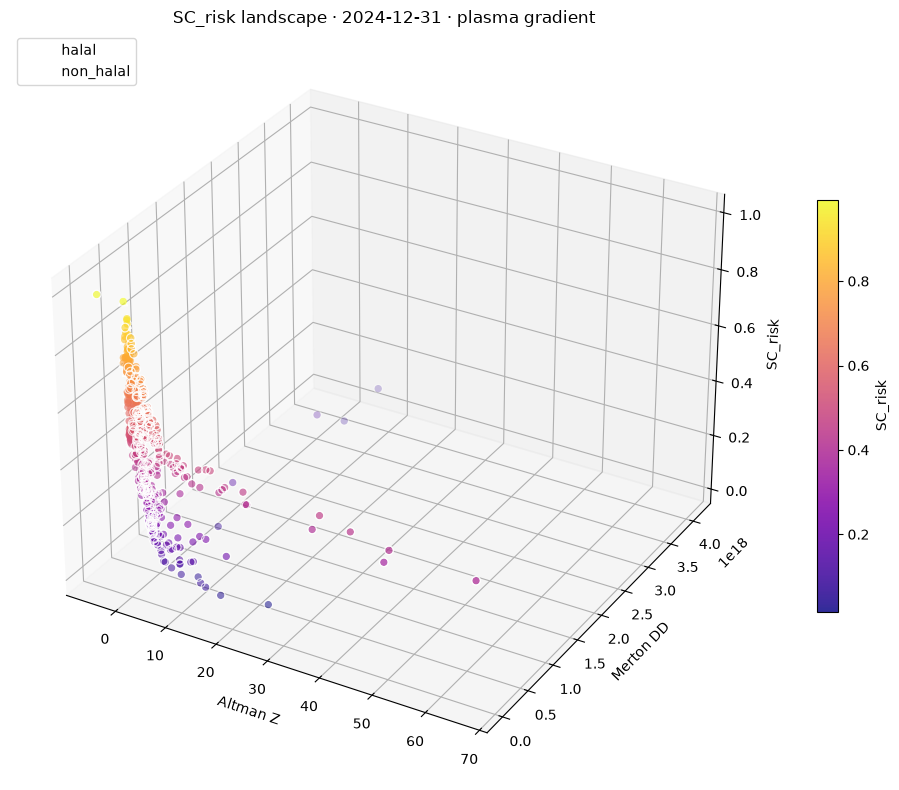

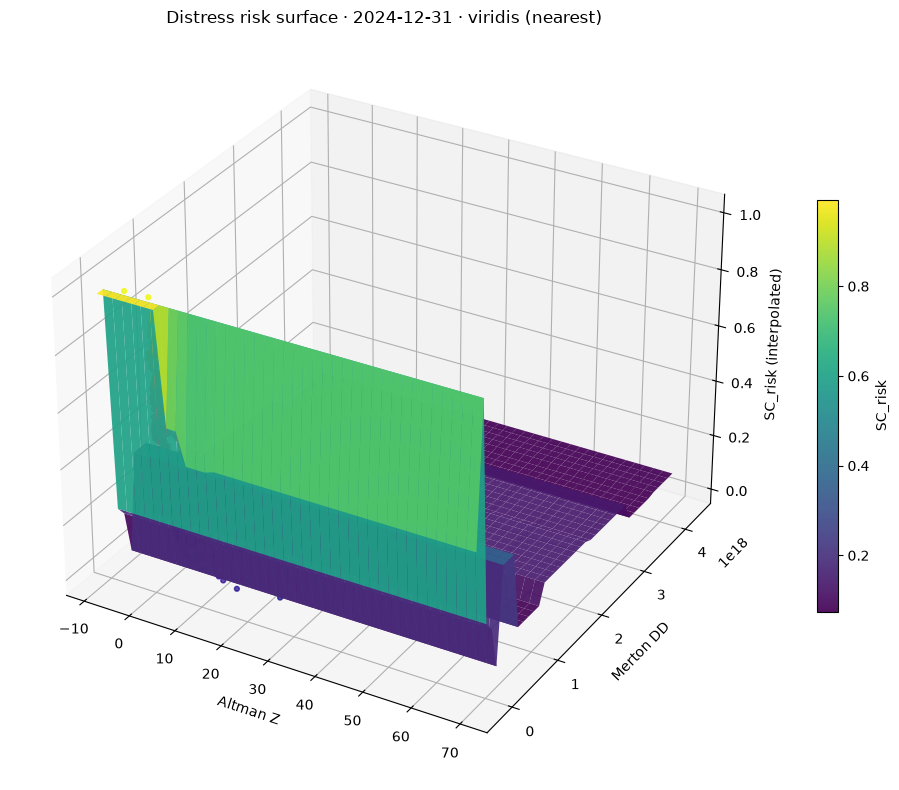

/var/folders/lf/wzrn2w4j7mq_hf01km30xn0c0000gn/T/ipykernel_5423/1681332120.py:84: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


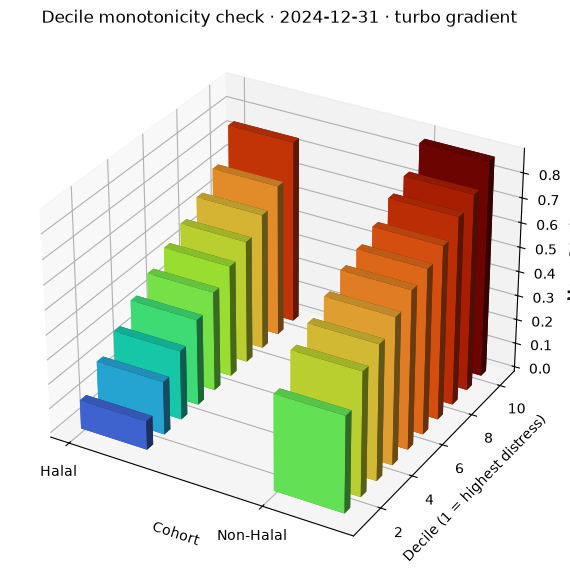

In [8]:
if snapshots.empty:
    print("No decile snapshots — skip 3D plots until backtest produces holdings.")
else:
    last_as_of = snapshots["as_of"].max()
    plot_df = snapshots[snapshots["as_of"] == last_as_of].copy()
    plot_df["debt_to_assets"] = plot_df["debt_ratio"].fillna(
        pd.to_numeric(plot_df.get("total_debt"), errors="coerce") / pd.to_numeric(plot_df.get("total_assets"), errors="coerce")
    )
    plot_df = plot_df.dropna(subset=["altman_z", "merton_dd", "sc_risk"])

    # --- 3D scatter: Z × DD × SC_risk with plasma gradient ---
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(
        plot_df["altman_z"],
        plot_df["merton_dd"],
        plot_df["sc_risk"],
        c=plot_df["sc_risk"],
        cmap="plasma",
        s=28,
        alpha=0.85,
        edgecolors="none",
    )
    for cohort, marker in ("halal", "o"), ("non_halal", "^"):
        sub = plot_df[plot_df["cohort"] == cohort]
        if not sub.empty:
            ax.scatter(sub["altman_z"], sub["merton_dd"], sub["sc_risk"], marker=marker, s=40, facecolors="none", edgecolors="white", linewidths=0.8, label=cohort)
    ax.set_xlabel("Altman Z")
    ax.set_ylabel("Merton DD")
    ax.set_zlabel("SC_risk")
    ax.set_title(f"SC_risk landscape · {last_as_of} · plasma gradient")
    fig.colorbar(sc, ax=ax, shrink=0.55, label="SC_risk")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(fig_dir / "sc-risk-3d-scatter.png", dpi=140)
    plt.show()

    # --- 3D surface: interpolated distress surface (viridis) ---
    surface = build_sc_risk_surface(plot_df)
    if surface is None:
        print(
            f"Skipping 3D surface — only {len(plot_df)} names with Z / DD / SC_risk. "
            "Scatter plot above is still valid; use full universe for a smooth surface."
        )
    else:
        X, Y, Z, interp_method = surface
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.92)
        ax.scatter(
            plot_df["altman_z"], plot_df["merton_dd"], plot_df["sc_risk"],
            c=plot_df["sc_risk"], cmap="plasma", s=12, depthshade=True,
        )
        ax.set_xlabel("Altman Z")
        ax.set_ylabel("Merton DD")
        ax.set_zlabel("SC_risk (interpolated)")
        ax.set_title(f"Distress risk surface · {last_as_of} · viridis ({interp_method})")
        fig.colorbar(surf, ax=ax, shrink=0.55, label="SC_risk")
        plt.tight_layout()
        plt.savefig(fig_dir / "sc-risk-3d-surface.png", dpi=140)
        plt.show()

    # --- 3D bar landscape: cohort × decile × mean SC_risk (turbo) ---
    mono = plot_df.groupby(["cohort", "decile"], as_index=False).agg(mean_sc_risk=("sc_risk", "mean"), n=("symbol", "count"))
    mono = mono[mono["n"] >= MIN_DECILE_SIZE]
    if not mono.empty:
        fig = plt.figure(figsize=(12, 7))
        ax = fig.add_subplot(111, projection="3d")
        cohort_idx = {"halal": 0, "non_halal": 1}
        xs = [cohort_idx[c] for c in mono["cohort"]]
        ys = mono["decile"].astype(float).tolist()
        zs = np.zeros(len(mono))
        dx = 0.35
        dy = 0.35
        dz = mono["mean_sc_risk"].values
        colors = plt.cm.turbo(mono["mean_sc_risk"] / mono["mean_sc_risk"].max())
        ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors, shade=True)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Halal", "Non-Halal"])
        ax.set_xlabel("Cohort")
        ax.set_ylabel("Decile (1 = highest distress)")
        ax.set_zlabel("Mean SC_risk")
        ax.set_title(f"Decile monotonicity check · {last_as_of} · turbo gradient")
        plt.tight_layout()
        plt.savefig(fig_dir / "decile-monotonicity-3d.png", dpi=140)
        plt.show()

## Step 8 — Measure performance vs benchmarks

Compare **Halal D10 − D1** and **Non-Halal D10 − D1** distress spreads against **SPY** and **SPUS**. Stats use the **live window** only (first day each spread has data).

Live window (Halal spread): 2023-01-03 → 2024-12-30 (501 days)
Live window (Non-Halal spread): 2023-03-31 → 2024-12-30 (440 days)


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Skew,Kurtosis
Strategy,,,,,,,,
Halal D10 − D1 spread,2.75%,11.97%,0.12,0.19,-9.61%,0.29,0.49,3.33
Non-Halal D10 − D1 spread,27.90%,16.09%,1.49,2.50,-11.77%,2.37,0.33,1.53
Halal low-distress (D10),31.74%,15.26%,1.75,2.53,-10.90%,2.91,-0.17,2.22
S&P 500,25.93%,12.82%,1.71,2.50,-9.97%,2.60,-0.26,0.73
Halal (SPUS),31.11%,15.07%,1.74,2.58,-11.46%,2.71,-0.20,0.53


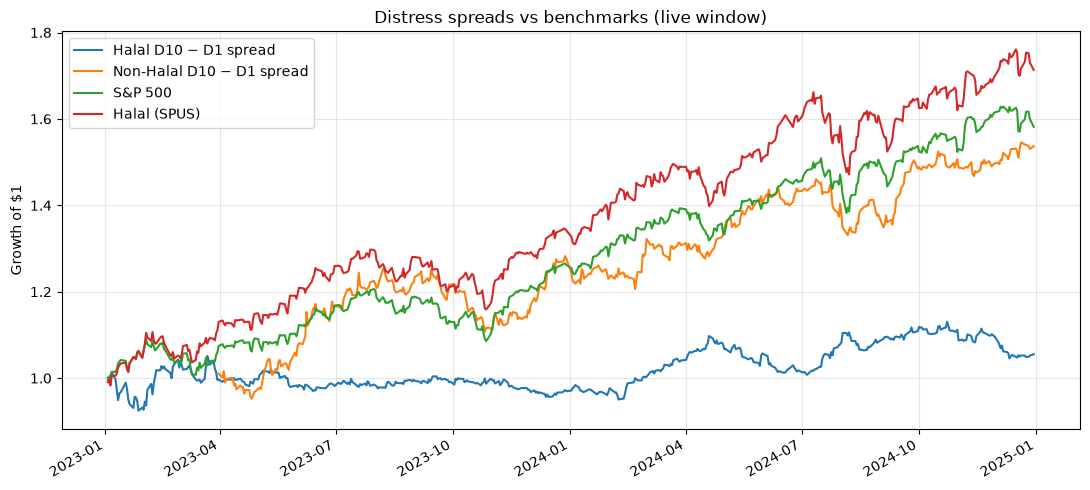

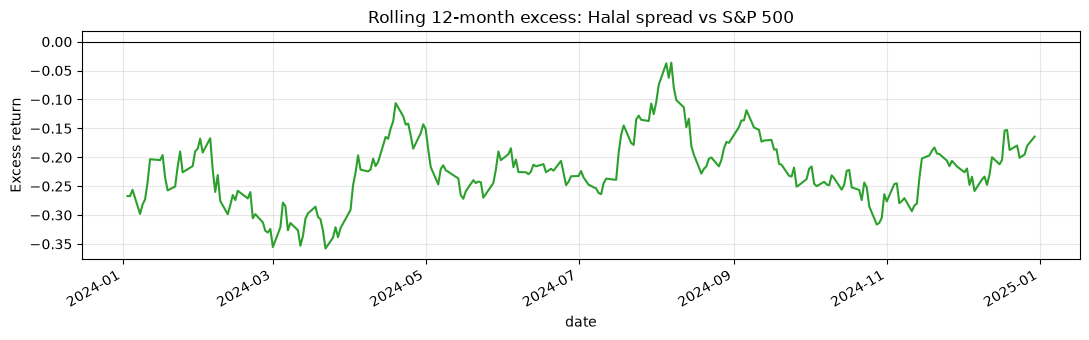

In [9]:
def benchmark_returns(ticker: str) -> pd.Series:
    px = prices[prices["symbol"] == ticker].copy()
    px["date"] = pd.to_datetime(px["date"])
    px = px.sort_values("date").set_index("date")["adj_close"]
    return px.pct_change(fill_method=None).dropna()


def align_to_live(strategy: pd.Series, benches: dict[str, pd.Series]) -> pd.DataFrame:
    strategy = strategy.copy()
    strategy.index = pd.to_datetime(strategy.index)
    panel_out = pd.DataFrame({"strategy": strategy})
    for name, series in benches.items():
        s = series.copy()
        s.index = pd.to_datetime(s.index)
        panel_out[name] = s
    return panel_out.dropna(how="any")


bench_series = {name: benchmark_returns(ticker) for name, ticker in BENCHMARKS.items()}
main_panel = align_to_live(halal_spread, bench_series).rename(columns={"strategy": SPREAD_HALAL_LABEL})
non_panel = align_to_live(non_spread, bench_series).rename(columns={"strategy": SPREAD_NON_HALAL_LABEL})

if main_panel.empty:
    raise RuntimeError("No overlapping live days for Halal spread — re-run data fetch cells.")

print(f"Live window (Halal spread): {main_panel.index.min().date()} → {main_panel.index.max().date()} ({len(main_panel)} days)")
if not non_panel.empty:
    print(f"Live window (Non-Halal spread): {non_panel.index.min().date()} → {non_panel.index.max().date()} ({len(non_panel)} days)")

rows = [calc_performance_stats(main_panel[SPREAD_HALAL_LABEL], SPREAD_HALAL_LABEL)]
if not non_panel.empty:
    rows.append(calc_performance_stats(non_panel[SPREAD_NON_HALAL_LABEL], SPREAD_NON_HALAL_LABEL))
rows.append(calc_performance_stats(halal_d10.reindex(main_panel.index).dropna(), HALAL_LABEL))
for name in BENCHMARKS:
    rows.append(calc_performance_stats(main_panel[name], name))
performance = pd.DataFrame(rows).set_index("Strategy")
display(performance.style.format(formatters))

plot_df = main_panel[[SPREAD_HALAL_LABEL]].copy()
if not non_panel.empty:
    plot_df[SPREAD_NON_HALAL_LABEL] = non_panel[SPREAD_NON_HALAL_LABEL]
for name in BENCHMARKS:
    plot_df[name] = main_panel[name]
equity_curves = (1 + plot_df).cumprod()
equity_curves.plot(figsize=(11, 5), title="Distress spreads vs benchmarks (live window)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.tight_layout()
plt.savefig(fig_dir / "equity-curves.png", dpi=140)
plt.show()

if "S&P 500" in main_panel.columns:
    rolling_excess = (
        (1 + main_panel[SPREAD_HALAL_LABEL]).rolling(252).apply(np.prod, raw=True)
        - (1 + main_panel["S&P 500"]).rolling(252).apply(np.prod, raw=True)
    )
    rolling_excess.plot(figsize=(11, 3.5), color="tab:green", title="Rolling 12-month excess: Halal spread vs S&P 500")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylabel("Excess return")
    plt.tight_layout()
    plt.savefig(fig_dir / "rolling-excess.png", dpi=140)
    plt.show()

## Step 9 — Drawdowns, decile monotonicity, rate-hike regimes

- **Drawdowns** — tail risk on the distress short leg (D1) vs safe leg (D10)
- **Decile bars** — monotonic return progression D1 → D10 within each cohort
- **Rate-hike windows** — does Non-Halal distress deteriorate faster than Halal during tightening?

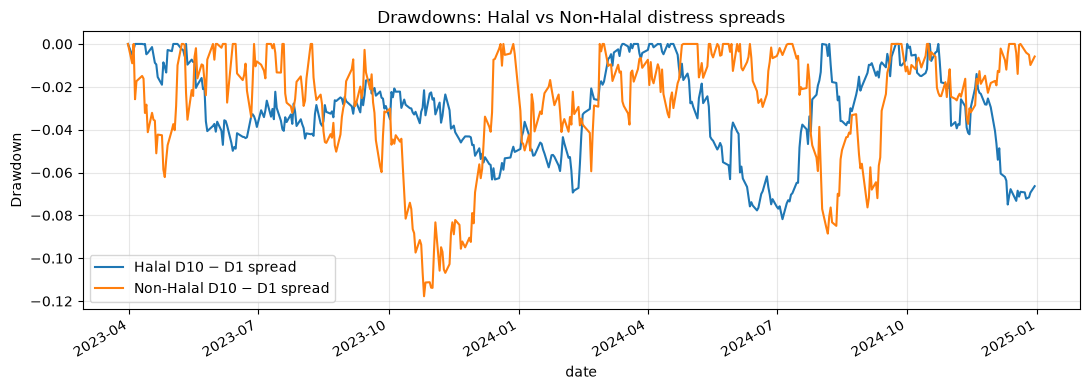

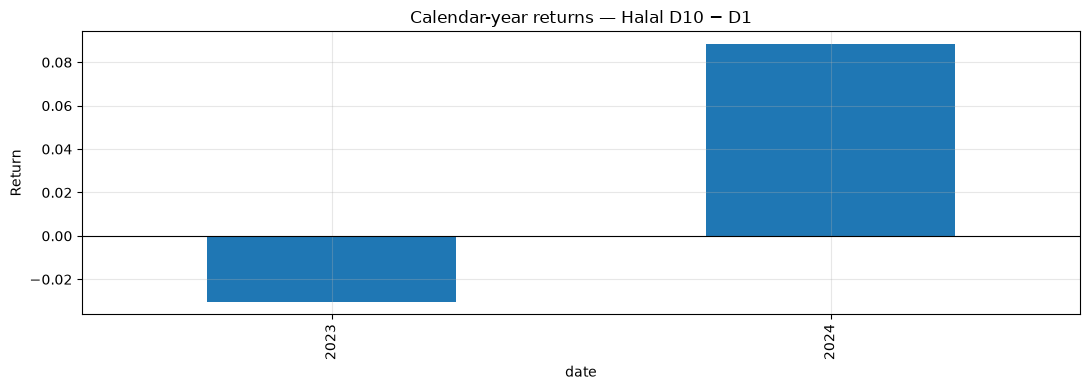

,CAGR,Max Drawdown,Sharpe,Skew,Kurtosis
Strategy,,,,,
halal_D1,27.17%,-11.16%,1.46,-0.19,0.25
halal_D2,22.80%,-11.82%,1.33,-0.16,0.41
halal_D3,31.72%,-10.91%,1.62,0.42,3.11
halal_D4,26.66%,-11.06%,1.58,-0.03,0.42
halal_D5,15.36%,-16.01%,0.87,-0.29,1.56
halal_D6,18.09%,-10.87%,1.10,-0.08,0.69
halal_D7,24.17%,-13.04%,1.39,0.30,1.84
halal_D8,23.83%,-15.58%,1.34,0.11,1.11
halal_D9,6.76%,-15.95%,0.38,-0.21,0.68


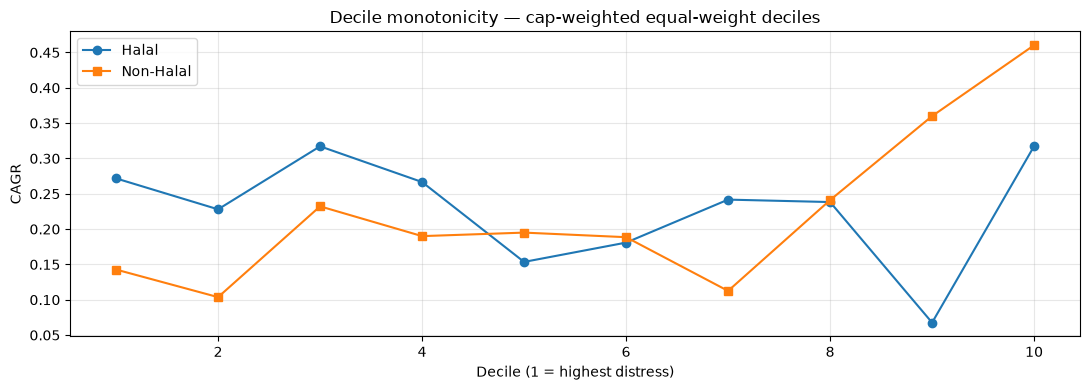

,Halal spread CAGR,Non-Halal spread CAGR,SPY CAGR
Window,,,
2022-03-01 → 2023-07-31,-2.55%,85.35%,38.81%


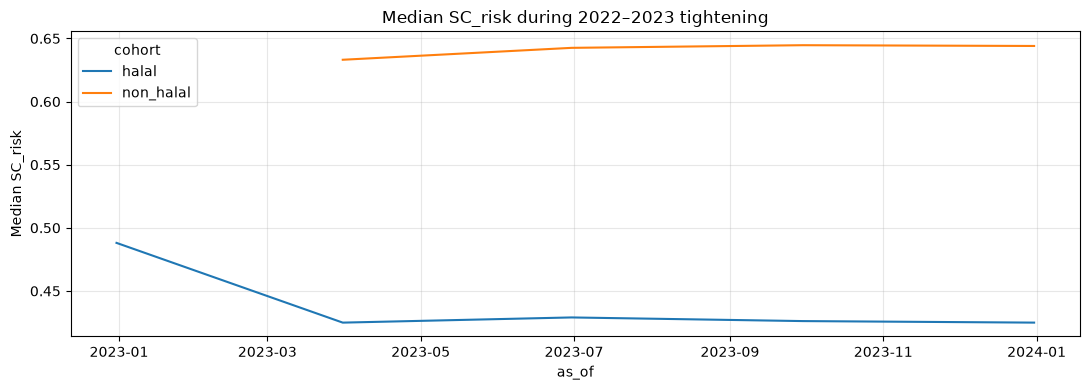

In [10]:
spread_panel = pd.DataFrame({SPREAD_HALAL_LABEL: halal_spread, SPREAD_NON_HALAL_LABEL: non_spread}).dropna(how="all")
spread_panel = spread_panel.reindex(main_panel.index).dropna(how="any")
equity_live = (1 + spread_panel).cumprod()
drawdowns = equity_live / equity_live.cummax() - 1
drawdowns.plot(figsize=(11, 4), title="Drawdowns: Halal vs Non-Halal distress spreads")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.savefig(fig_dir / "drawdowns.png", dpi=140)
plt.show()

# Calendar-year returns on Halal spread
yearly = (1 + main_panel[SPREAD_HALAL_LABEL]).resample("YE").prod() - 1
yearly.index = yearly.index.year
yearly.plot(kind="bar", figsize=(11, 4), title="Calendar-year returns — Halal D10 − D1")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Return")
plt.tight_layout()
plt.savefig(fig_dir / "calendar-year-returns.png", dpi=140)
plt.show()

# Decile CAGR monotonicity (live window)
decile_live = decile_returns.reindex(main_panel.index)
decile_stats = []
for col in decile_live.columns:
    decile_stats.append(calc_performance_stats(decile_live[col].dropna(), col))
decile_perf = pd.DataFrame(decile_stats).set_index("Strategy")
display(decile_perf[["CAGR", "Max Drawdown", "Sharpe", "Skew", "Kurtosis"]].style.format(formatters))

halal_cagrs = [decile_perf.loc[f"halal_D{d}", "CAGR"] for d in range(1, N_DECILES + 1) if f"halal_D{d}" in decile_perf.index]
non_cagrs = [decile_perf.loc[f"non_halal_D{d}", "CAGR"] for d in range(1, N_DECILES + 1) if f"non_halal_D{d}" in decile_perf.index]
fig, ax = plt.subplots(figsize=(11, 4))
if halal_cagrs:
    ax.plot(range(1, len(halal_cagrs) + 1), halal_cagrs, marker="o", label="Halal", color="tab:blue")
if non_cagrs:
    ax.plot(range(1, len(non_cagrs) + 1), non_cagrs, marker="s", label="Non-Halal", color="tab:orange")
ax.set_xlabel("Decile (1 = highest distress)")
ax.set_ylabel("CAGR")
ax.set_title("Decile monotonicity — cap-weighted equal-weight deciles")
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / "decile-monotonicity.png", dpi=140)
plt.show()

# Rate-hike regime table
regime_rows = []
for start, end in RATE_HIKE_WINDOWS:
    mask = (main_panel.index >= pd.Timestamp(start)) & (main_panel.index <= pd.Timestamp(end))
    sub = main_panel.loc[mask]
    if sub.empty:
        continue
    regime_rows.append({
        "Window": f"{start} → {end}",
        "Halal spread CAGR": calc_performance_stats(sub[SPREAD_HALAL_LABEL], "h")["CAGR"],
        "Non-Halal spread CAGR": calc_performance_stats(non_panel.reindex(sub.index)[SPREAD_NON_HALAL_LABEL].dropna(), "n")["CAGR"] if not non_panel.empty else np.nan,
        "SPY CAGR": calc_performance_stats(sub["S&P 500"], "spy")["CAGR"],
    })
if regime_rows:
    regime_df = pd.DataFrame(regime_rows).set_index("Window")
    display(regime_df.style.format("{:.2%}").set_caption("Rate-hike regime performance"))

# SC_risk deterioration during 2022–2023 hike (median by cohort)
if not snapshots.empty:
    hike_snaps = snapshots[pd.to_datetime(snapshots["as_of"]).between("2022-01-01", "2023-12-31")]
    if not hike_snaps.empty:
        med = hike_snaps.groupby(["as_of", "cohort"])["sc_risk"].median().unstack()
        med.plot(figsize=(11, 4), title="Median SC_risk during 2022–2023 tightening")
        plt.ylabel("Median SC_risk")
        plt.tight_layout()
        plt.savefig(fig_dir / "sc-risk-hike-cycle.png", dpi=140)
        plt.show()

## Step 10 — Attribution: alpha, beta, sector tilt

Is the Halal distress spread genuine alpha, or leverage-driven sector beta? We report CAPM stats vs SPY and SPUS, plus average sector weights in D10 (safe) books.

,Alpha (ann.),Beta,R²,Tracking error,Information ratio
Benchmark,,,,,
S&P 500,6.97%,-0.25,0.07,19.77%,-1.03
Halal (SPUS),8.46%,-0.27,0.11,22.18%,-1.12


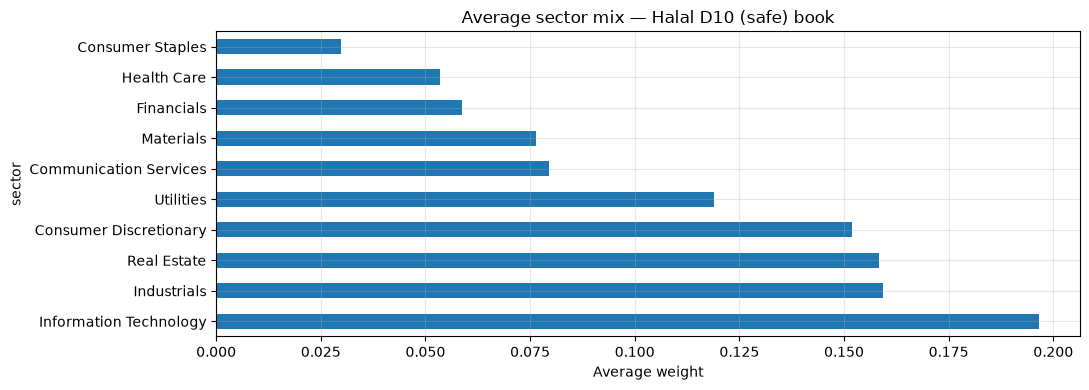

In [11]:
def capm_attribution(strategy: pd.Series, benchmark: pd.Series, rf: float = RISK_FREE_RATE) -> dict:
    aligned = pd.concat([strategy, benchmark], axis=1, keys=["y", "x"]).dropna()
    rf_d = rf / 252
    ye = aligned["y"] - rf_d
    xe = aligned["x"] - rf_d
    var_x = xe.var()
    beta = float(ye.cov(xe) / var_x) if var_x > 0 else np.nan
    alpha_d = float(ye.mean() - beta * xe.mean()) if pd.notna(beta) else np.nan
    resid = ye - alpha_d - beta * xe
    r2 = 1 - resid.var() / ye.var() if ye.var() > 0 else np.nan
    excess = aligned["y"] - aligned["x"]
    te = float(excess.std() * np.sqrt(252))
    ir = float(excess.mean() * 252 / te) if te > 0 else np.nan
    return {"Alpha (ann.)": alpha_d * 252, "Beta": beta, "R²": r2, "Tracking error": te, "Information ratio": ir}


attr_rows = []
for bench_name in BENCHMARKS:
    row = capm_attribution(main_panel[SPREAD_HALAL_LABEL], main_panel[bench_name])
    row["Benchmark"] = bench_name
    attr_rows.append(row)
attr = pd.DataFrame(attr_rows).set_index("Benchmark")
display(attr.style.format({
    "Alpha (ann.)": "{:.2%}", "Beta": "{:.2f}", "R²": "{:.2f}",
    "Tracking error": "{:.2%}", "Information ratio": "{:.2f}",
}).set_caption("Halal D10 − D1 spread vs benchmarks"))

if not snapshots.empty:
    gics_map = gics["gics_sector"].to_dict()
    d10_snaps = snapshots[snapshots["decile"] == N_DECILES]
    month_weights = []
    for as_of, snap in d10_snaps.groupby("as_of"):
        w = 1.0 / len(snap)
        month_weights.append(snap.assign(weight=w).assign(sector=lambda d: d["symbol"].map(gics_map).fillna("Unclassified")).groupby("sector")["weight"].sum())
    if month_weights:
        sector_mix = pd.concat(month_weights, axis=1).mean(axis=1).sort_values(ascending=False)
        sector_mix.plot(kind="barh", figsize=(11, max(4, 0.35 * len(sector_mix))), title="Average sector mix — Halal D10 (safe) book")
        plt.xlabel("Average weight")
        plt.tight_layout()
        plt.savefig(fig_dir / "sector-mix.png", dpi=140)
        plt.show()

## Step 11 — Friction: turnover, trading costs, short borrow, purification

Distress strategies bleed on turnover, short borrow on D1, and purification on dividends. We estimate trading-cost drag on the Halal spread and flag purification as a data gap if income is missing.

Item,Value
Rebalances with D10 holdings,9
Average names in Halal D10,24.3
Annualized one-way turnover,91.3%
Trading cost (one-way),10 bps
Illustrative short-borrow drag,5.0% ann.
CAGR gross of friction,2.75%
CAGR net of friction,0.81%


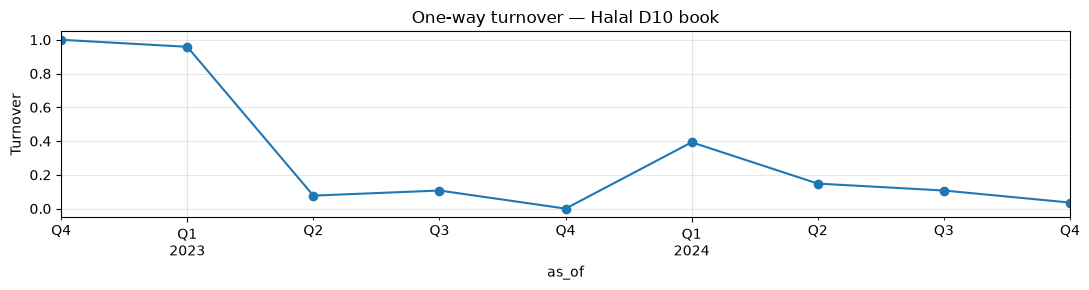

Fetching dividend purification for held names …


,symbol,ex_date,dividend,adj_dividend,record_date,payment_date,report_date,total_revenue,non_compliant_income,impure_ratio,purification_amount
0,A,2023-04-03,0.225,0.225,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000296
1,A,2023-06-30,0.225,0.225,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000296
2,A,2023-10-02,0.225,0.225,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000296
3,A,2023-12-29,0.236,0.236,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000310
4,A,2024-04-01,0.236,0.236,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001761
5,A,2024-07-02,0.236,0.236,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001761
6,A,2024-10-01,0.236,0.236,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001761
7,A,2024-12-31,0.248,0.248,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001851
8,AAPL,2023-02-10,0.230,0.230,NaT,NaT,2022-09-30,3.943280e+11,2.825000e+09,0.007164,0.001648
9,AAPL,2023-05-12,0.240,0.240,NaT,NaT,2022-09-30,3.943280e+11,2.825000e+09,0.007164,0.001719


In [12]:
def one_way_turnover(old: dict[str, float], new: dict[str, float]) -> float:
    if not new:
        return 0.0
    if not old:
        return 1.0
    names = set(old) | set(new)
    return 0.5 * sum(abs(new.get(s, 0.0) - old.get(s, 0.0)) for s in names)


def turnover_from_weights(weights_by_date: dict[date, pd.Series]) -> pd.DataFrame:
    rows = []
    prev: dict[str, float] = {}
    for as_of in sorted(weights_by_date):
        w = weights_by_date[as_of]
        curr = w.to_dict() if not w.empty else {}
        rows.append({"as_of": pd.Timestamp(as_of), "one_way": one_way_turnover(prev, curr), "n": len(curr)})
        prev = curr
    return pd.DataFrame(rows).set_index("as_of")


# Rebuild D10 weights for Halal cohort for turnover
halal_d10_weights: dict[date, pd.Series] = {}
if not snapshots.empty:
    for as_of, snap in snapshots[snapshots["cohort"] == "halal"].groupby("as_of"):
        chunk = snap[snap["decile"] == N_DECILES]
        if not chunk.empty:
            halal_d10_weights[as_of] = pd.Series(1.0 / len(chunk), index=chunk["symbol"].values)

turnover = turnover_from_weights(halal_d10_weights)
quarters = max(len(turnover) - 1, 1)
annual_turnover = turnover["one_way"].iloc[1:].sum() * (4 / quarters) if len(turnover) > 1 else np.nan
cost_drag_ann = annual_turnover * COST_BPS / 10_000
short_drag_ann = annual_turnover * SHORT_BORROW_ANN  # illustrative on short leg of spread

cost_on_day = pd.Series(0.0, index=main_panel.index)
for as_of, row in turnover.iterrows():
    hit = main_panel.index[main_panel.index >= as_of]
    if len(hit):
        cost_on_day.loc[hit[0]] += float(row["one_way"]) * (COST_BPS / 10_000 + SHORT_BORROW_ANN / 4)

net_returns = main_panel[SPREAD_HALAL_LABEL] - cost_on_day
net_stats = calc_performance_stats(net_returns, f"{SPREAD_HALAL_LABEL} net of costs")
gross_cagr = calc_performance_stats(main_panel[SPREAD_HALAL_LABEL], SPREAD_HALAL_LABEL)["CAGR"]

friction = pd.DataFrame({
    "Item": [
        "Rebalances with D10 holdings",
        "Average names in Halal D10",
        "Annualized one-way turnover",
        "Trading cost (one-way)",
        "Illustrative short-borrow drag",
        "CAGR gross of friction",
        "CAGR net of friction",
    ],
    "Value": [
        f"{len(turnover)}",
        f"{turnover['n'].mean():.1f}",
        f"{annual_turnover:.1%}",
        f"{COST_BPS} bps",
        f"{SHORT_BORROW_ANN:.1%} ann.",
        f"{gross_cagr:.2%}",
        f"{net_stats['CAGR']:.2%}",
    ],
})
display(friction.style.hide(axis="index"))

turnover["one_way"].plot(figsize=(11, 3), marker="o", title="One-way turnover — Halal D10 book")
plt.ylabel("Turnover")
plt.tight_layout()
plt.savefig(fig_dir / "turnover.png", dpi=140)
plt.show()

held_symbols = sorted(snapshots["symbol"].unique()) if not snapshots.empty else []
if held_symbols:
    print("Fetching dividend purification for held names …")
    try:
        purified = hq.purify_dividends(held_symbols, start=str(main_panel.index.min().date()), end=END)
        if purified.empty:
            print("No purification rows — report as data gap in the paper.")
        else:
            display(purified.head(10))
    except Exception as exc:
        print(f"Purification lookup failed ({exc}).")

### Notes on methodology

- **Point-in-time:** `halalquant.get_financial_metrics(..., freq="QE")` uses SEC filing dates with a conservative lag. Altman Z inputs come from yfinance annual statements with `FILING_LAG_DAYS`.
- **SC_risk:** Average percentile rank of **−Z** and **−DD** within each rebalance cross-section. Higher = more distress.
- **Cohorts:** **Halal** passes AAOIFI (`debt / 24m mcap < 33%`). **Non-Halal** = sector-eligible names that fail. Deciles are formed **within** each cohort.
- **Portfolios:** Equal-weight deciles. Spread = **D10 (safe) − D1 (distressed)**. Research note: live Sharia implementation may use long-only tilts toward D10 rather than shorting D1.
- **3D plots:** Scatter (plasma), interpolated surface (viridis), decile bar landscape (turbo) on the latest rebalance snapshot.
- **Rate hikes:** Pre-defined Fed tightening windows; extend `RATE_HIKE_WINDOWS` for full-sample tests.
- **White-paper map:** Steps 7–9 → section 3; Step 10 → section 4; Step 11 → section 5. Hypothesis (section 1) is in `research-plan.md`.
- **Runtime:** `FAST_MODE = False` on full S&P 500 takes ~20–50 min. Figures save to `Research/papers/03-financial-distress/figures/`.

## Summary

1. **SC_risk** blends accounting (Altman Z) and market-implied (Merton DD) distress signals.
2. **Halal debt screens** cap leverage before ranking — the core test is whether Halal cohorts show **lower SC_risk escalation** and **smaller drawdowns** in rate-hike regimes vs Non-Halal.
3. **Decile monotonicity** (D1 → D10) validates the factor; **3D landscapes** visualize where Halal names sit in the distress surface.
4. Report **gross and net-of-friction** spreads, and treat short-leg borrow + purification as real implementation costs.